In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Manejo de datos
import pandas as pd

# Computación numérica
import numpy as np

# Gráficas
from matplotlib import pyplot

%matplotlib inline

In [4]:
ruta = "/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Lab02/train.csv"

data = pd.read_csv(ruta)

print("Dataset cargado correctamente")

Dataset cargado correctamente


In [5]:
data.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [6]:
print("Cantidad de filas:", data.shape[0])
print("Cantidad de columnas:", data.shape[1])

m_total = data.shape[0]
n = data.shape[1] - 1

print("m =", m_total)
print("n =", n)

Cantidad de filas: 21263
Cantidad de columnas: 82
m = 21263
n = 81


In [7]:
print(data.columns.tolist())

['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie', 'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie', 'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie', 'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius', 'wtd_gmean_atomic_radius', 'entropy_atomic_radius', 'wtd_entropy_atomic_radius', 'range_atomic_radius', 'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius', 'mean_Density', 'wtd_mean_Density', 'gmean_Density', 'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density', 'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density', 'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity', 'gmean_ElectronAffinity', 'wtd_gmean_ElectronAffinity', 'entropy_ElectronAffinity', 'wtd_entropy_ElectronAffini

In [8]:
print("Datos nulos antes del preprocesamiento:")
print(data.isnull().sum().sum())

print("\nTipos de datos:")
print(data.dtypes.value_counts())

Datos nulos antes del preprocesamiento:
0

Tipos de datos:
float64    79
int64       3
Name: count, dtype: int64


In [9]:
data = data.apply(pd.to_numeric, errors="coerce")

print("Datos nulos después de convertir a numérico:")
print(data.isnull().sum().sum())

Datos nulos después de convertir a numérico:
0


In [10]:
if data.isnull().sum().sum() > 0:
    data = data.fillna(data.mean())

print("Datos preparados correctamente")

Datos preparados correctamente


In [11]:
datos_inferencia = data.tail(10).copy()

data_entrenamiento = data.iloc[:-10].copy()

print("Datos para entrenamiento:", data_entrenamiento.shape)
print("Datos reservados para inferencia:", datos_inferencia.shape)

Datos para entrenamiento: (21253, 82)
Datos reservados para inferencia: (10, 82)


In [12]:
X_df = data_entrenamiento.drop("critical_temp", axis=1)
y_df = data_entrenamiento["critical_temp"]

print("Dimensiones de X:", X_df.shape)
print("Dimensiones de y:", y_df.shape)

Dimensiones de X: (21253, 81)
Dimensiones de y: (21253,)


In [13]:
X = X_df.to_numpy(dtype=float)
y = y_df.to_numpy(dtype=float)

m = y.size

print("m =", m)
print("Número de características =", X.shape[1])

m = 21253
Número de características = 81


In [14]:
def featureNormalize(X):

    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evita división entre cero si alguna característica
    # tuviera desviación estándar igual a cero
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [15]:
X_norm, mu, sigma = featureNormalize(X)

print("Datos originales:")
print(X[:3])

print("\nDatos normalizados:")
print(X_norm[:3])

Datos originales:
[[4.00000000e+00 8.89444675e+01 5.78626923e+01 6.63615924e+01
  3.61166119e+01 1.18179524e+00 1.06239555e+00 1.22906070e+02
  3.17949209e+01 5.19688278e+01 5.36225345e+01 7.75425000e+02
  1.01026857e+03 7.18152900e+02 9.38016780e+02 1.30596704e+00
  7.91487788e-01 8.10600000e+02 7.35985714e+02 3.23811808e+02
  3.55562967e+02 1.60250000e+02 1.05514286e+02 1.36126003e+02
  8.45284227e+01 1.25924397e+00 1.20703999e+00 2.05000000e+02
  4.29142857e+01 7.52375405e+01 6.92355695e+01 4.65435725e+03
  2.96150229e+03 7.24953211e+02 5.35438109e+01 1.03312880e+00
  8.14598190e-01 8.95857100e+03 1.57958343e+03 3.30616290e+03
  3.57259662e+03 8.18375000e+01 1.11727143e+02 6.01231786e+01
  9.94146821e+01 1.15968659e+00 7.87381691e-01 1.27050000e+02
  8.09871429e+01 5.14337119e+01 4.25583958e+01 6.90550000e+00
  3.84685714e+00 3.47947485e+00 1.04098599e+00 1.08857534e+00
  9.94998193e-01 1.28780000e+01 1.74457143e+00 4.59906412e+00
  4.66691955e+00 1.07756645e+02 6.10151886e+01 7.062

In [16]:
X = np.concatenate(
    [np.ones((m, 1)), X_norm],
    axis=1
)

print("Dimensiones finales de X:", X.shape)

Dimensiones finales de X: (21253, 82)


In [17]:
def computeCostMulti(X, y, theta):

    m = y.shape[0]

    J = (1 / (2 * m)) * np.sum(
        np.square(np.dot(X, theta) - y)
    )

    return J

In [18]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):

        theta = theta - (alpha / m) * (
            np.dot(X, theta) - y
        ).dot(X)

        costo = computeCostMulti(X, y, theta)

        J_history.append(costo)

    return theta, J_history

In [19]:
alphas = [0.0003, 0.001, 0.003, 0.01]

num_iters_prueba = 300

resultados_alpha = {}

for alpha in alphas:

    theta_inicial = np.zeros(X.shape[1])

    theta_prueba, J_prueba = gradientDescentMulti(
        X,
        y,
        theta_inicial,
        alpha,
        num_iters_prueba
    )

    resultados_alpha[alpha] = J_prueba

    print(
        "Alpha:",
        alpha,
        "- Costo inicial:",
        J_prueba[0],
        "- Costo final:",
        J_prueba[-1]
    )

Alpha: 0.0003 - Costo inicial: 1173.8367154643774 - Costo final: 772.9573906243828
Alpha: 0.001 - Costo inicial: 1161.3553770782403 - Costo final: 566.9032002723312
Alpha: 0.003 - Costo inicial: 1127.0728478314857 - Costo final: 316.8163451843547
Alpha: 0.01 - Costo inicial: 1023.165767126942 - Costo final: 196.23736700829758


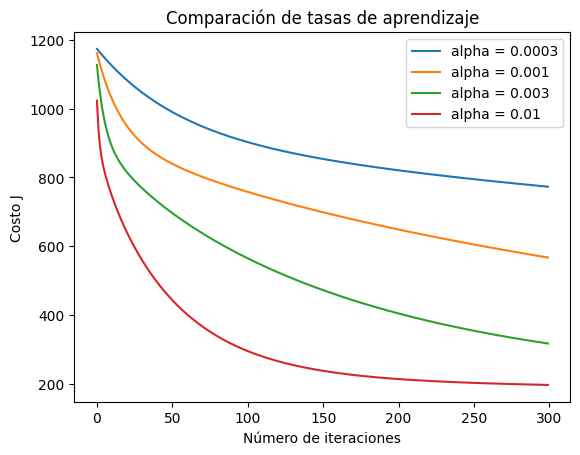

In [20]:
for alpha in alphas:

    pyplot.plot(
        np.arange(len(resultados_alpha[alpha])),
        resultados_alpha[alpha],
        label="alpha = " + str(alpha)
    )

pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title("Comparación de tasas de aprendizaje")
pyplot.legend()
pyplot.show()

In [21]:
mejor_alpha = None
menor_costo = float("inf")

for alpha in alphas:

    costo_final = resultados_alpha[alpha][-1]

    if np.isfinite(costo_final) and costo_final < menor_costo:

        menor_costo = costo_final
        mejor_alpha = alpha


print("Mejor alpha encontrado:", mejor_alpha)
print("Menor costo durante la prueba:", menor_costo)

Mejor alpha encontrado: 0.01
Menor costo durante la prueba: 196.23736700829758


In [22]:
alpha = mejor_alpha

num_iters = 2000

theta = np.zeros(X.shape[1])

theta, J_history = gradientDescentMulti(
    X,
    y,
    theta,
    alpha,
    num_iters
)

print("Entrenamiento terminado")

print("Costo inicial:", J_history[0])
print("Costo final:", J_history[-1])

Entrenamiento terminado
Costo inicial: 1023.165767126942
Costo final: 172.71566929212636


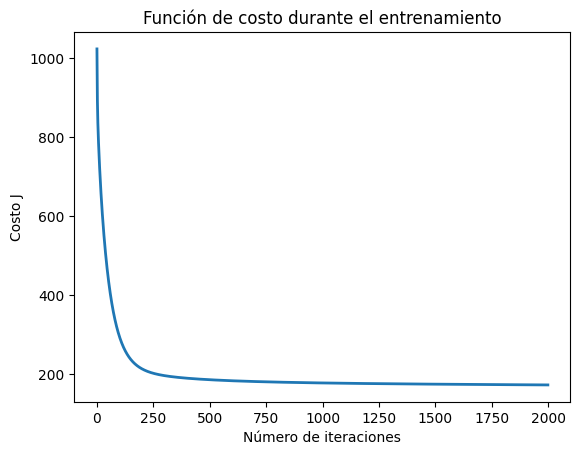

In [23]:
pyplot.plot(
    np.arange(len(J_history)),
    J_history,
    lw=2
)

pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title("Función de costo durante el entrenamiento")

pyplot.show()

In [24]:
print("Cantidad de parámetros theta:", len(theta))

print("\nPrimeros 10 theta:")
print(theta[:10])

Cantidad de parámetros theta: 82

Primeros 10 theta:
[34.43024143  1.92474961  2.12121572 -0.53144385  0.9478098   0.85818075
 -2.61822265  5.09886152  6.57318985 -2.49327847]


In [25]:
X_nuevos_df = datos_inferencia.drop(
    "critical_temp",
    axis=1
)

y_reales = datos_inferencia[
    "critical_temp"
].to_numpy(dtype=float)


X_nuevos = X_nuevos_df.to_numpy(dtype=float)

In [26]:
X_nuevos_norm = (X_nuevos - mu) / sigma

In [27]:
X_nuevos_final = np.concatenate(
    [
        np.ones((X_nuevos_norm.shape[0], 1)),
        X_nuevos_norm
    ],
    axis=1
)

In [28]:
predicciones = np.dot(
    X_nuevos_final,
    theta
)

In [32]:
resultados = pd.DataFrame({
    "Temperatura_real": y_reales,
    "Temperatura_predicha": predicciones
})

resultados["Error_absoluto"] = abs(
    resultados["Temperatura_real"]
    - resultados["Temperatura_predicha"]
)

print(resultados)

   Temperatura_real  Temperatura_predicha  Error_absoluto
0              1.60              7.573384        5.973384
1              3.00              7.573384        4.573384
2              1.42             14.741194       13.321194
3              1.85             14.741194       12.891194
4              3.43             14.741194       11.311194
5              2.44             21.058947       18.618947
6            122.10             90.703360       31.396640
7              1.98             -4.420018        6.400018
8              1.84             -4.696166        6.536166
9             12.80              0.017868       12.782132


In [33]:
error_promedio = resultados[
    "Error_absoluto"
].mean()

print(
    "Error absoluto promedio en las 10 inferencias:",
    error_promedio
)

Error absoluto promedio en las 10 inferencias: 12.380425164455172


In [34]:
print("===== RESUMEN DEL MODELO =====")

print("Registros originales:", m_total)
print("Datos utilizados para entrenamiento:", m)

print("Número de características:", n)

print("Mejor alpha:", mejor_alpha)

print("Número de iteraciones:", num_iters)

print("Costo inicial:", J_history[0])

print("Costo final:", J_history[-1])

print(
    "Error promedio de las 10 inferencias:",
    error_promedio
)

===== RESUMEN DEL MODELO =====
Registros originales: 21263
Datos utilizados para entrenamiento: 21253
Número de características: 81
Mejor alpha: 0.01
Número de iteraciones: 2000
Costo inicial: 1023.165767126942
Costo final: 172.71566929212636
Error promedio de las 10 inferencias: 12.380425164455172
